<a href="https://colab.research.google.com/github/shaipshiverya/Data_Analysis_python_projects/blob/main/japan_population_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
This analysis examines birth statistics and demographic trends in Japan over a century-long period. The dataset includes key variables such as total births, male births, female births, crude birth rate (CBR), and total fertility rate (TFR).

The investigation addresses several critical questions too.


# Importing the Dependencies

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Data Collection and Processing

In [3]:
df = pd.read_csv("/content/japan_birth_statistics_1899_2023.csv")
df.head()

,year,total_births,male_births,female_births,crude_birth_rate,sex_ratio_at_birth,total_fertility_rate
0,2023,727288,372603,354685,6.0,105.1,1.20
1,2022,770759,395257,375502,6.3,105.3,1.26
2,2021,811622,415903,395719,6.6,105.1,1.30
3,2020,840835,430713,410122,6.8,105.0,1.33
4,2019,865239,443430,421809,7.0,105.1,1.36


# Getting some basic informations about the data

In [4]:
print('Data Overview')
print('=' * 100)
print(f'Data Shape: {df.shape}')
print('=' * 100)
print('Available Columns:')
print(df.columns.tolist())
print(f"\n Data Types:")
print(df.dtypes)

Data Overview
Data Shape: (122, 7)
Available Columns:
['year', 'total_births', 'male_births', 'female_births', 'crude_birth_rate', 'sex_ratio_at_birth', 'total_fertility_rate']

 Data Types:
year                      int64
total_births              int64
male_births               int64
female_births             int64
crude_birth_rate        float64
sex_ratio_at_birth      float64
total_fertility_rate    float64
dtype: object


In [5]:
# getting the statistical measures of the data

df.describe()

,year,total_births,male_births,female_births,crude_birth_rate,sex_ratio_at_birth,total_fertility_rate
count,122.000000,1.220000e+02,1.220000e+02,1.220000e+02,122.000000,122.000000,77.000000
mean,1961.393443,1.619319e+06,8.304865e+05,7.888323e+05,20.824590,105.310656,1.860779
std,36.585812,4.392864e+05,2.249261e+05,2.144170e+05,10.534323,0.858387,0.696069
min,1899.000000,7.272880e+05,3.726030e+05,3.546850e+05,6.000000,102.700000,1.200000
25%,1929.250000,1.212138e+06,6.233448e+05,5.887932e+05,9.825000,104.900000,1.390000
50%,1962.500000,1.656495e+06,8.494710e+05,8.058480e+05,18.600000,105.300000,1.720000
75%,1992.750000,1.985486e+06,1.014098e+06,9.673500e+05,32.375000,105.800000,2.050000
max,2023.000000,2.696638e+06,1.380008e+06,1.316630e+06,36.200000,108.700000,4.540000


In [6]:
# checking the number of missing values

df.isna().sum()

,0
year,0
total_births,0
male_births,0
female_births,0
crude_birth_rate,0
sex_ratio_at_birth,0
total_fertility_rate,45


In [7]:
# Checking for the duplicate values

df.duplicated().sum()

np.int64(0)

# Imputing the data

In [8]:
df["total_fertility_rate"] = df["total_fertility_rate"].fillna(df["total_fertility_rate"].median())

In [9]:
#recheck

df.isna().sum()

,0
year,0
total_births,0
male_births,0
female_births,0
crude_birth_rate,0
sex_ratio_at_birth,0
total_fertility_rate,0


# EDA of the dataset

# Which years show a discrepancy where the total number of registered births is higher than the sum of male births + female births?

In [10]:
df['difference'] = df['total_births'] - (df['female_births'] + df['male_births'])
df[df['difference'] > 0]

,year,total_births,male_births,female_births,crude_birth_rate,sex_ratio_at_birth,total_fertility_rate,difference
85,1935,2190704,1122867,1067836,31.6,105.2,1.72,1
90,1930,2085101,1069551,1015549,32.4,105.3,1.72,1
94,1926,2104405,1081793,1022611,34.6,105.8,1.72,1


# YEAR WHICH HAS MAXIMUM BIRTH RATE

In [11]:
highest = df.groupby('year')['total_births'].sum().sort_values(ascending = False).head()
highest = highest.to_frame().reset_index()
highest['ranking'] = highest['total_births'].rank(method= 'dense',ascending= False).astype(int)
highest

,year,total_births,ranking
0,1949,2696638,1
1,1948,2681624,2
2,1947,2678792,3
3,1950,2337507,4
4,1941,2277283,5


# YEAR WHICH HAS MINIMUM BIRTH RATE

In [12]:
lowest = df.groupby('year')['total_births'].sum().sort_values(ascending=True).head(10)
lowest = lowest.to_frame().reset_index()
lowest['ranking'] = lowest['total_births'].rank(method='dense').astype(int)
lowest

,year,total_births,ranking
0,2023,727288,1
1,2022,770759,2
2,2021,811622,3
3,2020,840835,4
4,2019,865239,5
5,2018,918400,6
6,2017,946146,7
7,2016,977242,8
8,2014,1003609,9
9,2015,1005721,10


# Distribution of Total Births with Mean & Median

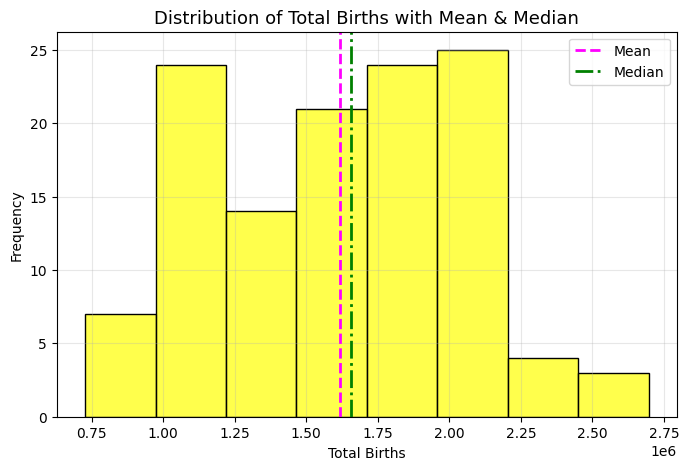

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['total_births'],color="yellow",edgecolor="black",alpha=0.7)

plt.axvline(df['total_births'].mean(),color="magenta",linestyle="--",linewidth=2,label="Mean")

plt.axvline(df['total_births'].median(),color="green",linestyle="-.",linewidth=2,label="Median")

plt.title("Distribution of Total Births with Mean & Median", fontsize=13)
plt.xlabel("Total Births")
plt.ylabel("Frequency")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Total Fertility Rate over the years

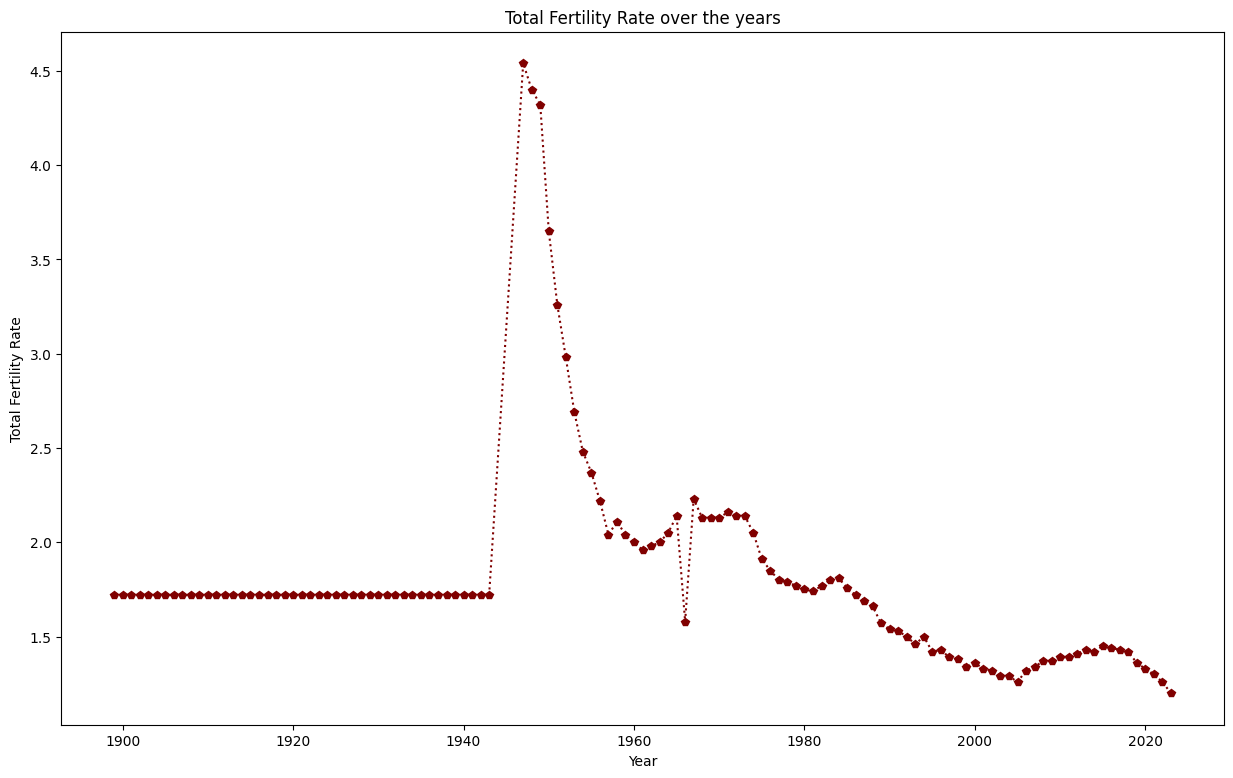

In [21]:
# total fertility rate over the years

plt.figure(figsize=(15,9))

plt.plot(df['year'], df['total_fertility_rate'],color= 'maroon',marker='p',linestyle=':')


plt.xlabel("Year")
plt.ylabel("Total Fertility Rate")
plt.title('Total Fertility Rate over the years')

plt.show()



# Is there a correlation between male and female child.

In [15]:
df[["male_births",'female_births']].corr()

,male_births,female_births
male_births,1.000000,0.999483
female_births,0.999483,1.000000


In [16]:
df[['total_births','total_fertility_rate']].corr()

,total_births,total_fertility_rate
total_births,1.000000,0.669746
total_fertility_rate,0.669746,1.000000


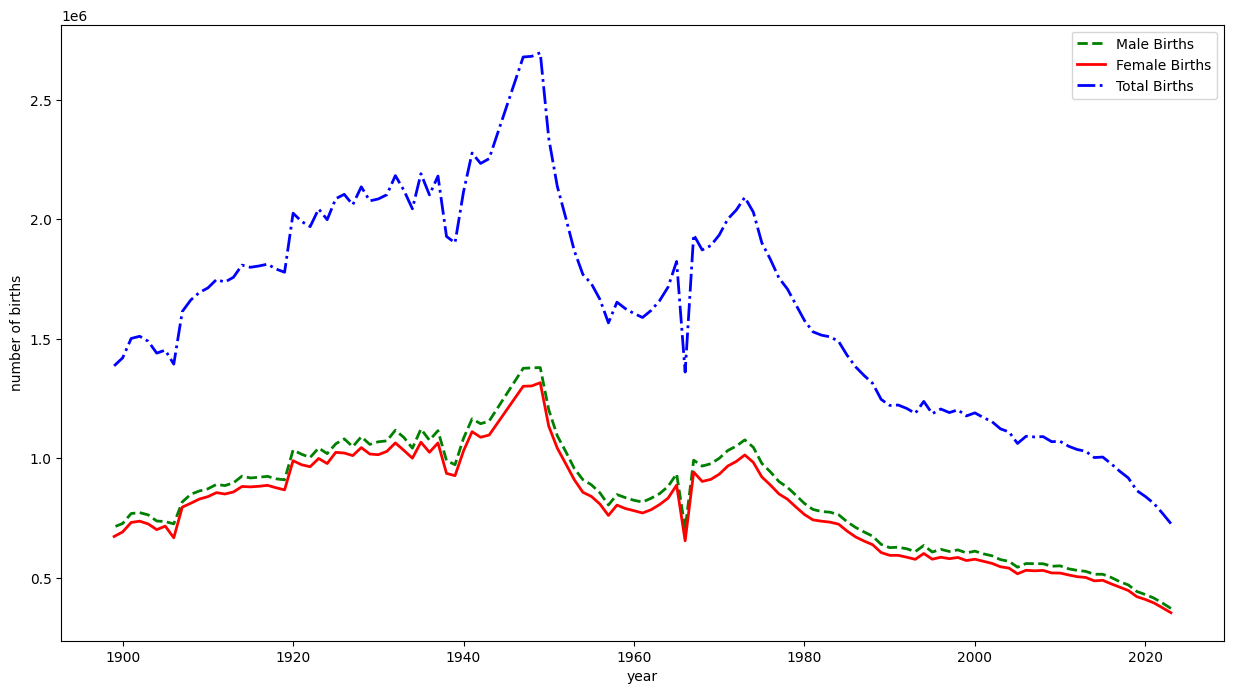

In [17]:
# Correlation

plt.figure(figsize=(15,8))

plt.plot(df['year'],df['male_births'],color='green',linestyle= '--',linewidth=2,label='Male Births')
plt.plot(df['year'],df['female_births'],color='red',linestyle= '-',linewidth=2,label='Female Births')
plt.plot(df['year'],df['total_births'],color='blue',linestyle= '-.',linewidth=2,label='Total Births')

plt.xlabel('year')
plt.ylabel('number of births')

plt.legend()

plt.show()

# *these are highly correalated*

# **The total births, male births, female births are highly correlated**

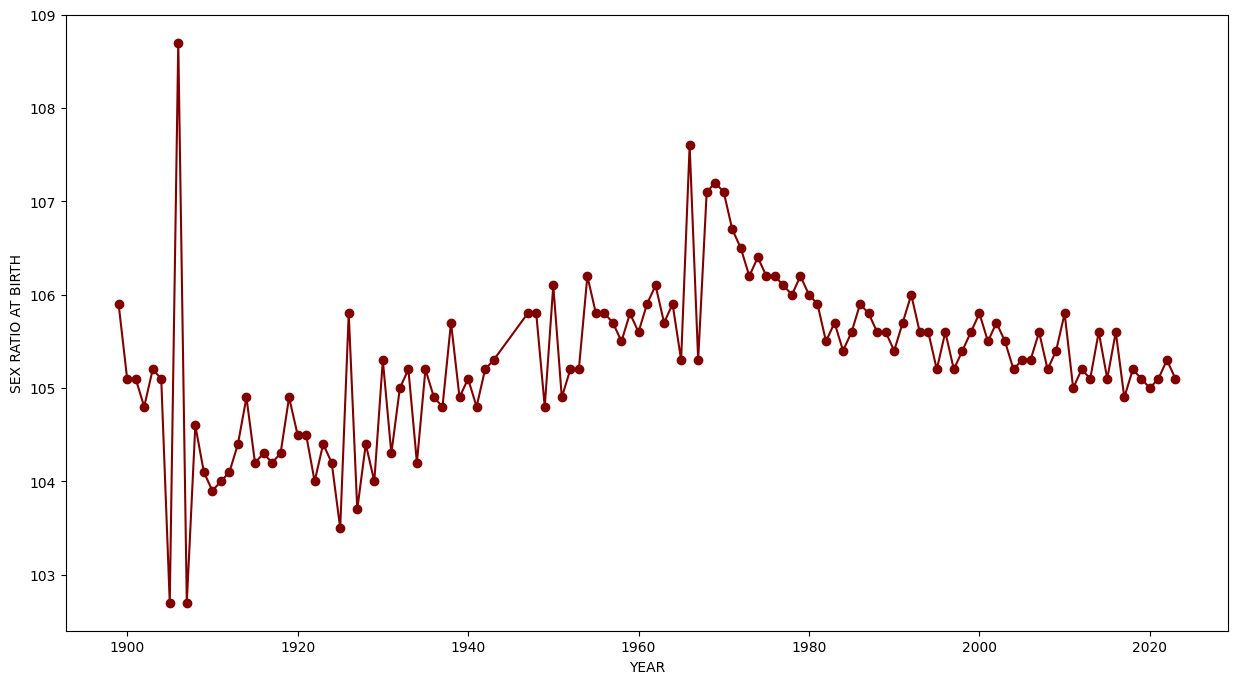

In [18]:
plt.figure(figsize=(15,8))

plt.plot(df['year'],df['sex_ratio_at_birth'],color="maroon",marker="o")

plt.xlabel('YEAR')
plt.ylabel('SEX RATIO AT BIRTH')

plt.show()

# The sex ratio is stable over 100+ years. No major systematic gender selection at birth has been noticed.
# *Slight peak around 1965–1970 — but still not much.*

# How the crude birth rate and fertility rate changes over time in **japan**




In [ ]:
df[['crude_birth_rate', 'total_fertility_rate']].corr()

,crude_birth_rate,total_fertility_rate
crude_birth_rate,1.000000,0.355351
total_fertility_rate,0.355351,1.000000


TFR shows fewer children per woman.

CBR shows structural demographic change (aging population + fewer women of childbearing age).

Japan’s crisis is not just “women having fewer kids”, it’s also that there are fewer young people left to have kids